,net_alpha,gross_alpha,gap_gross_minus_net,net_p_alpha,net_signif_5%,gross_p_alpha,gross_signif_5%
Group,,,,,,,
ACTIVE portfolio,0.0335,0.0416,0.0081,0.1858,No,0.1012,No
PASSIVE portfolio,0.0467,0.0506,0.0039,0.0496,Yes,0.0337,Yes


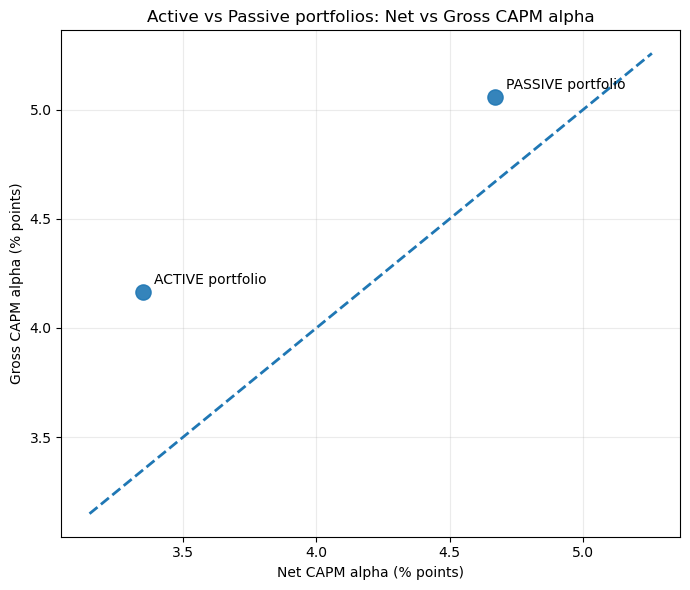

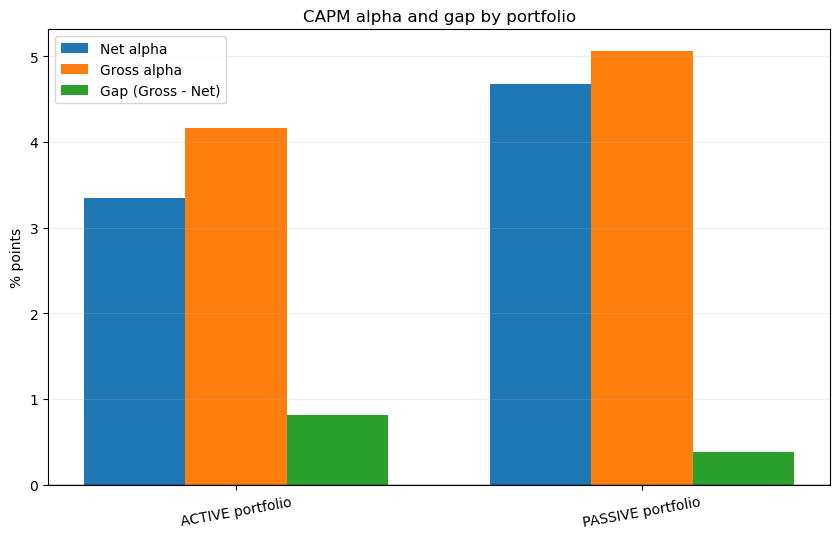

In [4]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from IPython.display import display

# -------------------- LOAD --------------------
fund_net   = pd.read_excel("project Funds_2026.xlsx", sheet_name="Net")
fund_gross = pd.read_excel("project Funds_2026.xlsx", sheet_name="Gross")
info       = pd.read_excel("project Funds_2026.xlsx", sheet_name="Info")
f          = pd.read_excel("project Factors_2026.xlsx")

# -------------------- PREP --------------------
f[["rf","rm_rf","smb_vw","hml_vw"]] *= 12
fund_net.iloc[:,3:]   *= 12
fund_gross.iloc[:,3:] *= 12

f = f.rename(columns={"year":"Year","month":"Month"})
fac = f[["Year","Month","rf","rm_rf"]].copy()

net   = fund_net.merge(fac, on=["Year","Month"], how="inner")
gross = fund_gross.merge(fac, on=["Year","Month"], how="inner")

fund_cols = fund_net.columns[3:]

# -------------------- FIND NAME/TYPE --------------------
info_cols_lower = {c.lower(): c for c in info.columns}
name_col = next((info_cols_lower[c] for c in ["fund name", "fund_name", "name"] if c in info_cols_lower), None)
type_col = next((info_cols_lower[c] for c in ["fund type", "fund_type", "type"] if c in info_cols_lower), None)

if name_col is None or type_col is None:
    raise ValueError("Hittar inte 'Fund name' och/eller 'fund type' i Info-sheeten.")

info_map = (
    info[[name_col, type_col]]
    .copy()
    .drop_duplicates(subset=[name_col])
    .set_index(name_col)
)

types = info_map[type_col].astype(str).str.strip().str.lower()
fund_type_series = types.reindex(fund_cols)

# Passive = index-based equity fund + passively managed equity fund
is_passive = fund_type_series.isin(["index-based equity fund", "passively managed equity fund"])
is_active  = fund_type_series.eq("actively managed equity fund")

passive_funds = fund_type_series.index[is_passive].tolist()
active_funds  = fund_type_series.index[is_active].tolist()

if len(passive_funds) == 0:
    raise ValueError("Hittade 0 passiva fonder. Kolla stavning i Info -> fund type.")
if len(active_funds) == 0:
    raise ValueError("Hittade 0 aktiva fonder. Kolla stavning i Info -> fund type.")

# -------------------- BUILD PORTFOLIO RETURNS (equal-weight) --------------------
def make_portfolios(df, active_list, passive_list):
    out = df[["Year","Month","rf","rm_rf"]].copy()

    out["ACTIVE_ret"]  = df[active_list].apply(pd.to_numeric, errors="coerce").mean(axis=1, skipna=True)
    out["PASSIVE_ret"] = df[passive_list].apply(pd.to_numeric, errors="coerce").mean(axis=1, skipna=True)

    out["ACTIVE_excess"]  = out["ACTIVE_ret"]  - pd.to_numeric(out["rf"], errors="coerce")
    out["PASSIVE_excess"] = out["PASSIVE_ret"] - pd.to_numeric(out["rf"], errors="coerce")
    return out

ports_net   = make_portfolios(net,   active_funds, passive_funds)
ports_gross = make_portfolios(gross, active_funds, passive_funds)

# -------------------- CAPM --------------------
def capm_alpha(excess, rm_rf):
    df = pd.DataFrame({"excess": excess, "rm_rf": rm_rf}).apply(pd.to_numeric, errors="coerce").dropna()
    X = sm.add_constant(df["rm_rf"])
    fit = sm.OLS(df["excess"], X).fit()
    alpha = fit.params.get("const", np.nan)
    pval  = fit.pvalues.get("const", np.nan)
    return alpha, pval

def yesno(p):
    return "Yes" if (pd.notna(p) and p < 0.05) else "No"

# ACTIVE
a_net_alpha, a_net_p = capm_alpha(ports_net["ACTIVE_excess"],   ports_net["rm_rf"])
a_gro_alpha, a_gro_p = capm_alpha(ports_gross["ACTIVE_excess"], ports_gross["rm_rf"])

# PASSIVE
p_net_alpha, p_net_p = capm_alpha(ports_net["PASSIVE_excess"],   ports_net["rm_rf"])
p_gro_alpha, p_gro_p = capm_alpha(ports_gross["PASSIVE_excess"], ports_gross["rm_rf"])

# -------------------- OUTPUT TABLE (ONLY requested columns) --------------------
out = pd.DataFrame([
    {
        "Group": "ACTIVE portfolio",
        "net_alpha": a_net_alpha,
        "gross_alpha": a_gro_alpha,
        "gap_gross_minus_net": a_gro_alpha - a_net_alpha,
        "net_p_alpha": a_net_p,
        "net_signif_5%": yesno(a_net_p),
        "gross_p_alpha": a_gro_p,
        "gross_signif_5%": yesno(a_gro_p),
    },
    {
        "Group": "PASSIVE portfolio",
        "net_alpha": p_net_alpha,
        "gross_alpha": p_gro_alpha,
        "gap_gross_minus_net": p_gro_alpha - p_net_alpha,
        "net_p_alpha": p_net_p,
        "net_signif_5%": yesno(p_net_p),
        "gross_p_alpha": p_gro_p,
        "gross_signif_5%": yesno(p_gro_p),
    }
]).set_index("Group")

display(
    out.style.format({
        "net_alpha": "{:.4f}",
        "gross_alpha": "{:.4f}",
        "gap_gross_minus_net": "{:.4f}",
        "net_p_alpha": "{:.4f}",
        "gross_p_alpha": "{:.4f}",
    })
)

# ==================== GRAPHS ====================

# ---------- PLOT 1: Scatter Net vs Gross alpha (2 portfolios) ----------
plt.figure(figsize=(7, 6))
x = 100 * out["net_alpha"]
y = 100 * out["gross_alpha"]
plt.scatter(x, y, s=120, alpha=0.9)

for idx in out.index:
    plt.annotate(idx, (100*out.loc[idx, "net_alpha"], 100*out.loc[idx, "gross_alpha"]),
                 textcoords="offset points", xytext=(8, 6))

xy_min = min(x.min(), y.min())
xy_max = max(x.max(), y.max())
pad = 0.2
plt.plot([xy_min - pad, xy_max + pad], [xy_min - pad, xy_max + pad], linestyle="--", linewidth=2)

plt.xlabel("Net CAPM alpha (% points)")
plt.ylabel("Gross CAPM alpha (% points)")
plt.title("Active vs Passive portfolios: Net vs Gross CAPM alpha")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


# ---------- PLOT 2: Grouped bars (Net, Gross, Gap) ----------
plt.figure(figsize=(8.5, 5.5))
grp = (out[["net_alpha", "gross_alpha", "gap_gross_minus_net"]] * 100).copy()

xpos = np.arange(len(grp.index))
w = 0.25
plt.bar(xpos - w, grp["net_alpha"], width=w, label="Net alpha")
plt.bar(xpos,     grp["gross_alpha"], width=w, label="Gross alpha")
plt.bar(xpos + w, grp["gap_gross_minus_net"], width=w, label="Gap (Gross - Net)")

plt.axhline(0, linewidth=1, color="black")
plt.xticks(xpos, grp.index, rotation=10)
plt.ylabel("% points")
plt.title("CAPM alpha and gap by portfolio")
plt.grid(True, axis="y", alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

